In [1]:
import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from model import get_model
from forward_operator import get_operator
from sampler import get_sampler


/home/jovyan/project/Deep_Learning_DAPS/daps_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model config (ddpm)
model_cfg_path = 'configs/model/ffhq256ddpm.yaml'
model_cfg = OmegaConf.load(model_cfg_path)
model = get_model(**model_cfg).cuda()
model.eval()

# Load task/operator config
task_cfg_path = 'configs/task/scribble_inpainting.yaml'
task_cfg = OmegaConf.load(task_cfg_path)

# Use pixel-space box inpainting
pixel_cfg = task_cfg.pixel
operator_cfg = pixel_cfg.operator
mcmc_cfg = pixel_cfg.mcmc_sampler_config

print("Operator config:", operator_cfg)
print("MCMC config:", mcmc_cfg)



Operator config: {'name': 'scribble_inpainting', 'mask_path': 'Irregular_mask/00020.jpg', 'resolution': 256, 'sigma': 0.05}
MCMC config: {'num_steps': 100, 'lr': 5e-05, 'tau': 0.01, 'lr_min_ratio': 0.01, 'mc_algo': 'langevin', 'prior_solver': 'gaussian'}


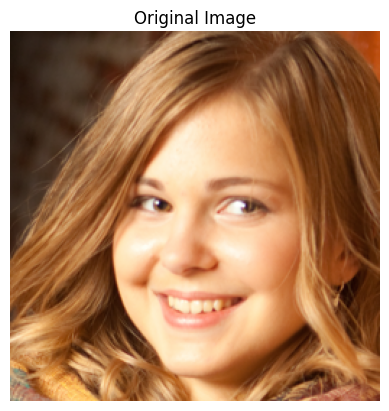

In [3]:
# Load and preprocess a test image
image_path = "dataset/test-ffhq/49013.png"
img = Image.open(image_path).resize((operator_cfg.resolution, operator_cfg.resolution))
img = torch.tensor(np.array(img)).float() / 255.0
img = img.permute(2,0,1).unsqueeze(0).cuda()  # [1,3,H,W]

plt.imshow(img[0].permute(1,2,0).cpu())
plt.title("Original Image")
plt.axis("off")
plt.show()


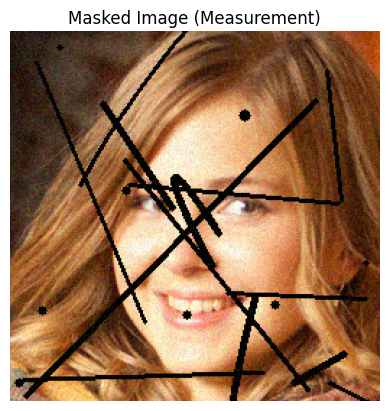

In [6]:
operator = get_operator(**operator_cfg)

# Forward pass to create measurement (masked input)
y = operator.measure(img)         # masked image
mask = operator.mask       # mask generated inside the operator

plt.imshow(y[0].permute(1,2,0).cpu().clamp(0,1))
# plt.imshow(mask[0][0].cpu().clamp(0,1))
plt.title("Masked Image (Measurement)")
plt.axis("off")
plt.show()


In [7]:
from omegaconf import OmegaConf

# Load sampler YAML
sampler_cfg_path = "configs/sampler/edm_daps.yaml"
sampler_cfg = OmegaConf.load(sampler_cfg_path)


In [8]:

# Construct sampler
sampler = get_sampler(
    latent=sampler_cfg.latent,
    annealing_scheduler_config=sampler_cfg.annealing_scheduler_config,
    diffusion_scheduler_config=sampler_cfg.diffusion_scheduler_config,
    mcmc_sampler_config=mcmc_cfg  # from pixel/inpainting config
)

# sampler = sampler.to(device)


In [9]:
# DAPS requires a starting point
x_start = sampler.get_start(batch_size=1, model=model)


In [10]:
# Run DAPS
# with torch.no_grad():
result = sampler.sample(
        model=model,
        x_start=x_start,
        operator=operator,
        measurement=y,
        verbose=True
    )


100%|██████████| 200/200 [00:33<00:00,  5.95it/s]


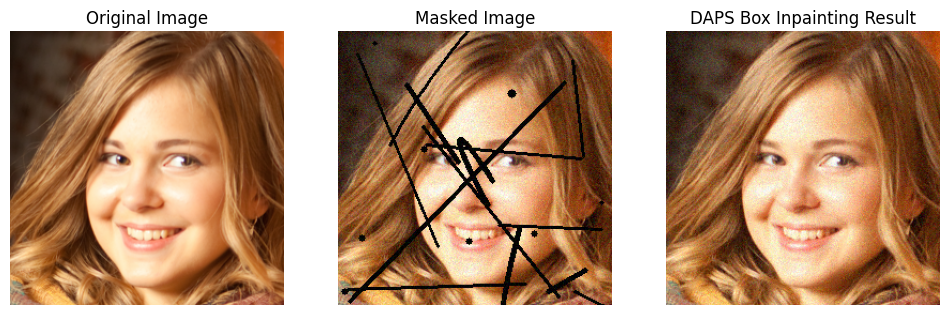

In [11]:

# result shape: [1, C, H, W]
daps_res_img = result[0].cpu().permute(1, 2, 0).clamp(0, 1)
mask_img = y[0].permute(1,2,0).cpu().clamp(0,1)
orig_img = img[0].cpu().permute(1, 2, 0).clamp(0, 1)
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

# Original Image
ax[0].imshow(orig_img)
ax[0].set_title("Original Image")
ax[0].axis("off")
#Mask image
ax[1].imshow(mask_img)
ax[1].set_title("Masked Image")
ax[1].axis("off")
# 4. Plot Result Image on the right (index 1)
ax[2].imshow(daps_res_img)
ax[2].set_title("DAPS Box Inpainting Result")
ax[2].axis("off")

plt.show()


In [14]:
img_array = np.array(mask[0][0].cpu())
print("Unique pixel values found:", np.unique(img_array))

Unique pixel values found: [0. 1.]


Unique pixel values found: [  0   1   2   3   4   5   6   7 247 248 249 250 251 252 253 254 255]


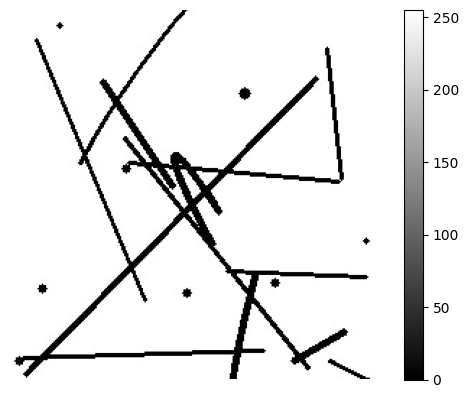

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
# 1. Load the image using PIL (standard way to read files)
img = Image.open("Irregular_mask/00020.jpg")
img_array = np.array(img)
print("Unique pixel values found:", np.unique(img_array))
# 2. Plot the image using Matplotlib
plt.imshow(img,cmap="gray")
plt.colorbar()
plt.axis('off')  # Optional: Removes the ruler numbers on the side
plt.show()

In [15]:

# 1. Load the image
img = Image.open("Irregular_mask/00020.jpg").convert('L')
img_array = np.array(img)

print("Original Range:", img_array.min(), "-", img_array.max())

# 2. Normalize to 0.0 - 1.0
# Just dividing by 255.0 converts it to float range [0, 1]
normalized_array = img_array / 255.0

# 3. Threshold (Binarize) to force exactly 0.0 or 1.0
# Values > 0.5 become 1.0, values <= 0.5 become 0.0
# This removes "gray" edges caused by JPG compression
binary_mask = (normalized_array > 0.5).astype(np.float32)

print("New Unique Values:", np.unique(binary_mask)) 

Original Range: 0 - 255
New Unique Values: [0. 1.]


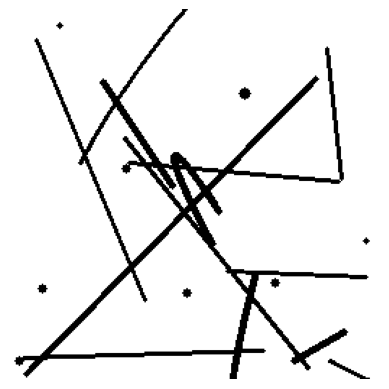

In [17]:
plt.imshow(binary_mask,cmap="gray")

plt.axis('off')  # Optional: Removes the ruler numbers on the side
plt.show()